# One-Dimensional Localized Reaction-Diffusion Front
 We start with the equation
 $$\partial_t \theta = \kappa \partial_x^2 \theta + S(\theta), \qquad \theta \in [0,\theta_h]$$
 where
 $$S(\theta) = S_0 * 0.5 * \Big( \tanh \Big ( \dfrac{\theta - \theta_* + \epsilon/2}{0.01} \Big ) - \tanh \Big ( \dfrac{\theta - \theta_* - \epsilon/2}{0.01} \Big ) \Big ) $$

 This is a smooth top-hat function.

 $S_0>0$ represents heating, and $S_0<0$ represents cooling. I will be looking at the cooling case, but this notebook should work for either if you change the value of $S_0$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (7, 4.2)

# Parameters and Characterisitc Scales

We define all parameters and characteristic scales using the cold state $\theta = 0$ as a reference. We define the reaction time as
$$t_\text{react} = \dfrac{\theta_*}{|S_0|}$$
We then have an estimated length and speed of
$$\ell_\text{est} \sim \sqrt{\dfrac{\kappa \theta_*}{|S_0|}}, \qquad v_\text{est} \sim \sqrt{\dfrac{\kappa |S_0|}{\theta_*}}$$

*Note*: There is a separate time, $\epsilon/|S_0|$, that must be resolved numerically. This is the time to cross the active top-hat interval.

In [ ]:
# Parameters
theta_h = 1.0

# user input params, were originally theta_star = 0.5, eps = 0.1, kappa = 1.0, S0 = -1.0 : baseline case
while True:
    try:
        S0 = float(input("Enter a value for S0 between -1.5 and 1.5: "))
        if -1.5 <= S0 <= 1.5:
            break
        else:
            print("error: the value must be between -1.5 and 1.5")
    except ValueError:
        print("error: that is not a valid number")
print(f"S0 value accepted")

while True:
    try:
        theta_star = float(input("Enter a value for theta_star between 0.2 and 0.8: "))
        if 0.2 <= theta_star <= 0.8:
            break
        else:
            print("error: the value must be between 0.2 and 0.8")
    except ValueError:
        print("error: that is not a valid number")
print(f"theta_star value accepted")

while True:
    try:
        eps = float(input("Enter a value for epsilon between 0.01 and 0.3: "))
        if 0.01 <= eps <= 0.3:
            break
        else:
            print("error: the value must be between 0.01 and 0.3")
    except ValueError:
        print("error: that is not a valid number")
print(f"eps value accepted")

while True:
    try:
        kappa = float(input("Enter a value for kappa between 0.25 and 1.75: "))
        if 0.25 <= kappa <= 1.75:
            break
        else:
            print("error: the value must be between 0.25 and 1.75")
    except ValueError:
        print("error: that is not a valid number")
print(f"kappa value accepted")

absS0 = abs(S0)

# characteristic scales
t_react = theta_star/absS0
l_est = np.sqrt(kappa*theta_star/absS0)
v_est = np.sqrt(kappa*absS0/theta_star)
t_cross = eps/absS0

print(f"t_react = theta*/|S0|        = {t_react:.4f}")
print(f"l_est   = sqrt(k*theta*/|S0|)= {l_est:.4f}")
print(f"v_est   = sqrt(k*|S0|/theta*)= {v_est:.4f}")
print(f"t_cross = eps/|S0|           = {t_cross:.4f}  (band-crossing time, must be resolved)")

S0 value accepted
theta_star value accepted
eps value accepted
kappa value accepted
t_react = theta*/|S0|        = 0.5000
l_est   = sqrt(k*theta*/|S0|)= 0.7071
v_est   = sqrt(k*|S0|/theta*)= 1.4142
t_cross = eps/|S0|           = 0.2000  (band-crossing time, must be resolved)


# Numerical Setup
Domain:
$$x \in [-L/2, L/2], \qquad L >> \ell_\text{front}$$
Boundary values:
$$\theta(-L/2,t)=0, \qquad \theta(L/2,t)=\theta_h$$
Initial Condition:
$$\theta(x,0)=\frac{\theta_h}{2}\Big(1+\tanh\frac{x-x_0}{w_0}\Big),$$
which goes smoothly from $\approx 0$ on the left to $\approx \theta_h$ on the right, centered at $x_0$.

In [3]:
# set domain and make the grid
def make_grid(L, N):
    x = np.linspace(-L/2.0, L/2.0, N)
    dx = x[1] - x[0]
    return x, dx

# set initial conditions and boundary conditions
def initial_condition(x, theta_h, x0, w0):
    theta = 0.5*theta_h*(1.0 + np.tanh((x - x0)/w0))
    theta[0]  = 0.0
    theta[-1] = theta_h
    return theta

# Baseline numerical parameters
L   = 60.0
N   = 5000     # number of grid points
x0  = 0.0
w0  = 1.0

x, dx = make_grid(L, N)
theta0 = initial_condition(x, theta_h, x0, w0)
print(f"L={L}, N={N}, dx={dx:.5f},  l_est/dx = {l_est/dx:.1f}")

L=60.0, N=5000, dx=0.01200,  l_est/dx = 58.9


# The source term, spatial discretization, and the time step

Source term: $S(\theta)$, which is equal to $S_0$ when close to $\theta_*$ and 0 otherwise.

Spatial derivative approximation: we use second-order centered differences (averaging the slope at the beginning and end of an interval) to approximate the second spatial derivative of $\theta$:
$$\partial_x^2\theta \approx \dfrac{\theta_{i+1}-2\theta_i + \theta_{i-1}}{\Delta x^2}$$
where the index $i$ is the point where $\theta$ is evaluated. This approximation is valid on the interior nodes; the edge nodes are fixed by the boundary conditions.

Thus, we can rewrite the approximated PDE as
$$f_i(\theta) = \kappa \Big( \dfrac{\theta_{i+1}-2\theta_i + \theta_{i-1}}{\Delta x^2} \Big) + S(\theta_i)$$
At the boundary nodes, $f=0$.

In addition, we employ two restrictions on the time step to our explicit scheme:
$$\Delta t \lesssim 0.4\,\dfrac{\Delta x^2}{\kappa} \qquad \text{and} \qquad \Delta t \ll \dfrac{\varepsilon}{|S_0|}$$
so that the simulation does not blow up and so that enough points are sampled in the active region, respectively.

In [4]:
# source term
def source(theta, S0, eps, theta_star):
    return S0 * 0.5 * (np.tanh((theta - theta_star + (eps/2)) / 0.01) - np.tanh((theta - theta_star - (eps/2)) / 0.01))

# rhs of approximated PDE, keep boundary vals at 0
def rhs(theta, kappa, dx, S0, eps, theta_star):
    f = np.zeros_like(theta)
    lap = (theta[2:] - 2.0*theta[1:-1] + theta[:-2]) / dx**2
    f[1:-1] = kappa*lap + source(theta[1:-1], S0, eps, theta_star)
    return f

# choose time step to be smaller of the two bounds
def choose_dt(dx, kappa, eps, S0, cfl=0.4, react_safety=0.2):
    dt_diff  = cfl * dx**2 / kappa
    dt_react = react_safety * eps / abs(S0)
    return min(dt_diff, dt_react)

dt = choose_dt(dx, kappa, eps, S0)
print(f"dt_diff = 0.4*dx^2/kappa = {0.4*dx**2/kappa:.3e}")
print(f"dt_react = 0.2*eps/|S0| = {0.2*eps/abs(S0):.3e}")
print(f"chosen dt = {dt:.3e}  ->  steps to cross band = {(eps/abs(S0))/dt:.0f}")

dt_diff = 0.4*dx^2/kappa = 5.762e-05
dt_react = 0.2*eps/|S0| = 4.000e-02
chosen dt = 5.762e-05  ->  steps to cross band = 3471


# RK2 Time Integration

We will use an RK2 integration method to advance through time:
$$k_1=f(\theta^n),\quad \tilde\theta=\theta^n+\Delta t\,k_1,\quad k_2=f(\tilde\theta),\quad
\theta^{n+1}=\theta^n+\tfrac{\Delta t}{2}\,(k_1+k_2).$$

In [5]:
# one RK2 step
def step_rk2(theta, dt, kappa, dx, S0, eps, theta_star):
    k1 = rhs(theta, kappa, dx, S0, eps, theta_star)
    k2 = rhs(theta + dt*k1, kappa, dx, S0, eps, theta_star)
    return theta + 0.5*dt*(k1 + k2)

# Measurements

The front position is defined by $\theta(x_f,t)=\theta_*$, using interpolation between grid points (estimating its position using two neighboring points). Using this, we measure
$$v_f(t)=\dfrac{dx_f}{dt}$$
We also track an interface width:
$$\ell_{10-90} = x(0.9\theta_h)-x(0.1\theta_h)$$
from linear interpolation of the level crossings.

In [6]:
# all x where \theta(x) equals a specific value, found by linear interpolation
def all_crossings(x, theta, level):
    d = theta - level
    idx = np.where(((d[:-1] <= 0.0) & (d[1:] > 0.0)) | 
                   ((d[:-1] >= 0.0) & (d[1:] < 0.0)))[0]
    out = []
    for i in idx:
        denom = d[i] - d[i+1]
        frac = 0.0 if denom == 0.0 else d[i] / denom
        out.append(x[i] + frac * (x[i+1] - x[i]))
    return np.array(out)

def front_position(x, theta, theta_star, prev=None):
    xs = all_crossings(x, theta, theta_star)
    if len(xs) == 0:
        return np.nan
    if prev is None or np.isnan(prev):
        return xs[0]
    return xs[np.argmin(np.abs(xs - prev))]

def front_position_cold(x, theta, theta_star, eps):
    xs = all_crossings(x, theta, theta_star - eps/2)
    if len(xs) == 0:
        return np.nan
    x_center = 0.5 * (x[0] + x[-1])
    return xs[np.argmin(np.abs(xs - x_center))]

def front_position_hot(x, theta, theta_star, eps):
    xs = all_crossings(x, theta, theta_star + eps/2)
    if len(xs) == 0:
        return np.nan
    x_center = 0.5 * (x[0] + x[-1])
    return xs[np.argmin(np.abs(xs - x_center))]

def width_10_90(x, theta, theta_h):
    xlo = all_crossings(x, theta, 0.1*theta_h)
    xhi = all_crossings(x, theta, 0.9*theta_h)
    if len(xlo) == 0 or len(xhi) == 0:
        return np.nan
    return xhi[-1] - xlo[0]

def width_cold(x, theta, theta_h, theta_star, eps):
    xlo = all_crossings(x, theta, 0.1*theta_h)
    xhi = all_crossings(x, theta, theta_star - eps/2)
    if len(xlo) == 0 or len(xhi) == 0:
        return np.nan
    return xhi[-1] - xlo[0]

def width_hot(x, theta, theta_h, theta_star, eps):
    xlo = all_crossings(x, theta, theta_star + eps/2)
    xhi = all_crossings(x, theta, 0.9*theta_h)
    if len(xlo) == 0 or len(xhi) == 0:
        return np.nan
    return xhi[-1] - xlo[0]

# Simulation

In [7]:
# changed t_end to user input bc we want the front to reach x=10 and the time for it to do that depends on the parameter values
# NEXT STEP: should implement t_end to automatically be the time where the front reaches x=10
while True:
    try:
        t_end = float(input("Enter a value for t_end between 5.0 and 100.0: "))
        if 5.0 <= t_end <= 100.0:
            break
        else:
            print("error: the value must be between 5.0 and 100.0")
    except ValueError:
        print("error: that is not a valid number")
print(f"t_end value accepted")

def simulate(kappa=kappa, S0=S0, eps=eps, theta_star=theta_star, theta_h=theta_h,
             L=L, N=N, x0=x0, w0=w0, t_end=t_end, cfl=0.4, dt=None, n_record=240,
             n_snaps=12):
    x, dx = make_grid(L, N)
    if dt is None:
        dt = choose_dt(dx, kappa, eps, S0, cfl=cfl)
    theta = initial_condition(x, theta_h, x0, w0)

    nsteps = int(round(t_end/dt))
    rec = max(1, nsteps // n_record)          # record
    snap_every = max(1, nsteps // (n_snaps-1))   # snapshot

    ts, xfs, wds, wcs, whs, xfcs, xfhs = [], [], [], [], [], [], []
    snaps, snap_t = [], []
    prev = np.nan
    t = 0.0
    for n in range(nsteps + 1):
        if n % rec == 0:
            prev = front_position(x, theta, theta_star, prev)
            ts.append(t); xfs.append(prev); wds.append(width_10_90(x, theta, theta_h)); wcs.append(width_cold(x, theta, theta_h, theta_star, eps)); whs.append(width_hot(x, theta, theta_h, theta_star, eps)); xfcs.append(front_position_cold(x, theta, theta_star, eps)); xfhs.append(front_position_hot(x, theta, theta_star, eps))
        if n % snap_every == 0 or n == nsteps:
            snaps.append(theta.copy()); snap_t.append(t)
        theta = step_rk2(theta, dt, kappa, dx, S0, eps, theta_star)
        t += dt

    return dict(x=x, dx=dx, dt=dt, t=np.array(ts), xf=np.array(xfs), wd=np.array(wds), wc=np.array(wcs), wh=np.array(whs), xfc=np.array(xfcs), xfh=np.array(xfhs), 
                theta=theta, snaps=snaps, snap_t=snap_t,
                kappa=kappa, S0=S0, eps=eps, theta_star=theta_star, theta_h=theta_h, L=L)

base = simulate()
print(f"steps used dt={base['dt']:.2e}; recorded {len(base['t'])} frames; "
      f"final xf={base['xf'][-1]:.3f}, final width={base['wd'][-1]:.3f}")
print([f"{t:.3f}" for t in base['snap_t']])

t_end value accepted
steps used dt=5.76e-05; recorded 241 frames; final xf=23.971, final width=30.799
['0.000', '1.818', '3.636', '5.455', '7.273', '9.091', '10.909', '12.727', '14.545', '16.364', '18.182', '20.000']


# Profile evolution of the front

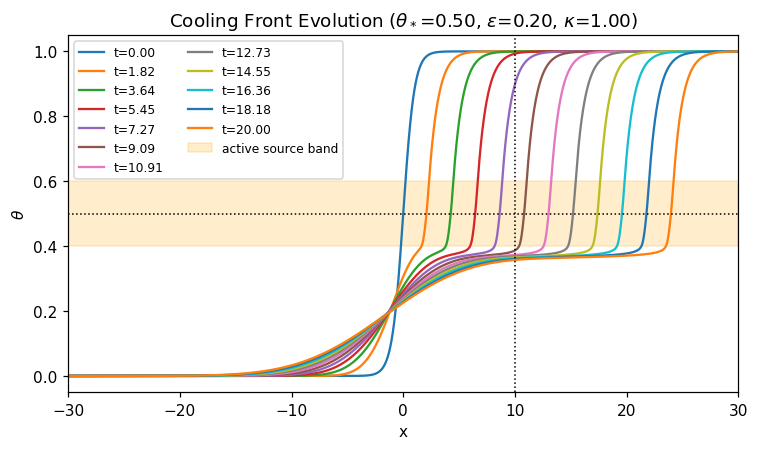

In [8]:
fig, ax = plt.subplots()
for th, tt in zip(base['snaps'], base['snap_t']):
    ax.plot(base['x'], th, label=f"t={tt:.2f}")
ax.axhline(theta_star, ls=':', c='k', lw=1)
ax.axhspan(theta_star-eps/2, theta_star+eps/2, color='orange', alpha=0.2,
           label='active source band')
ax.axvline(10, ls=':', c='k', lw=1)
ax.set_xlabel('x'); ax.set_ylabel(r'$\theta$')
ax.set_xlim(-L/2, L/2); ax.set_title(f"Cooling Front Evolution ($\\theta_*$={theta_star:.2f}, $\\epsilon$={eps:.2f}, $\\kappa$={kappa:.2f})")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

# Profile evolution of the front - split at band edge

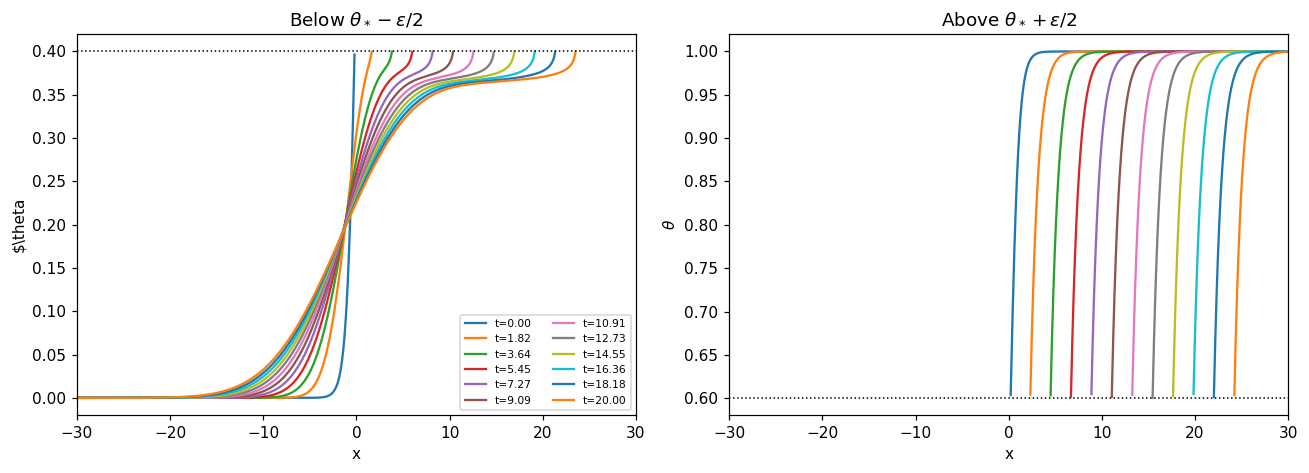

In [9]:
# plotting the profile split in two parts
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12,4.4))
for th, tt in zip(base['snaps'], base['snap_t']):
    th = np.asarray(th)
    below = np.where(th <= theta_star - eps/2, th, np.nan)
    above = np.where(th >= theta_star + eps/2, th, np.nan)
    axL.plot(base['x'], below, label=f"t={tt:.2f}")
    axR.plot(base['x'], above, label=f"t={tt:.2f}")

axL.axhline(theta_star - eps/2, ls=':', c='k', lw=1)
axL.set_title(r'Below $\theta_* - \epsilon /2$')
axL.set_xlabel('x'); axL.set_ylabel(r'$\theta'); axL.set_xlim(-L/2, L/2)
axL.legend(fontsize=7, ncol=2)

axR.axhline(theta_star + eps/2, ls=':', c='k', lw=1)
axR.set_title(r'Above $\theta_* + \epsilon /2$')
axR.set_xlabel('x'); axR.set_ylabel(r'$\theta$'); axR.set_xlim(-L/2, L/2)

plt.tight_layout(); plt.show()

# Measured quantities vs time

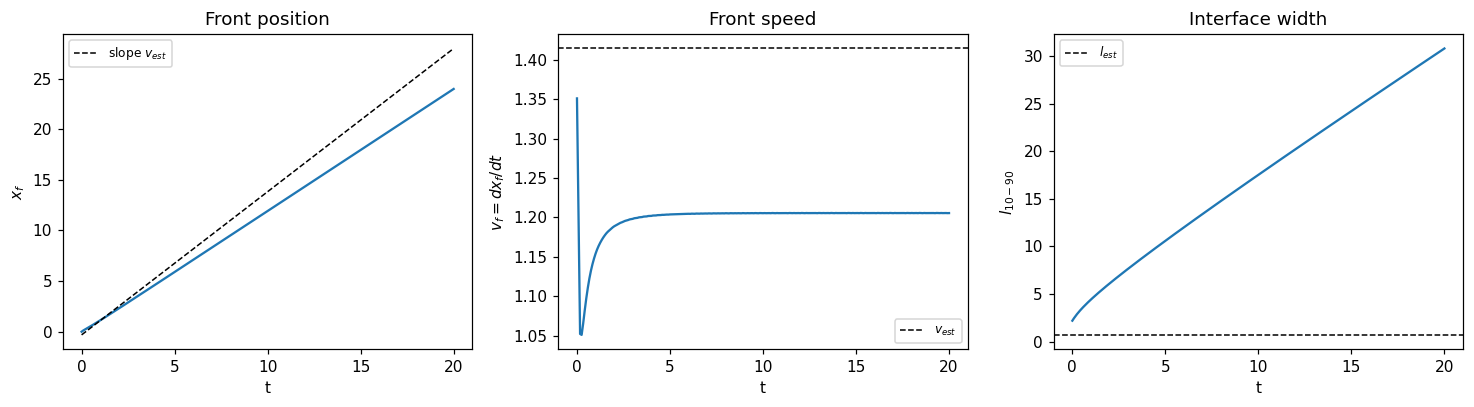

late-time mean speed  ~  1.2051   (v_est = 1.4142)
late-time mean width  ~  20.2022   (l_est = 0.7071)


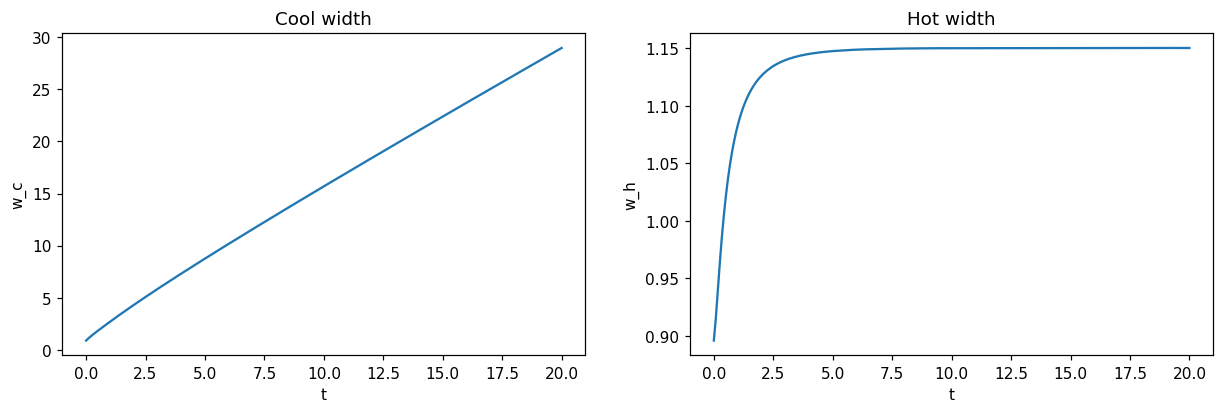

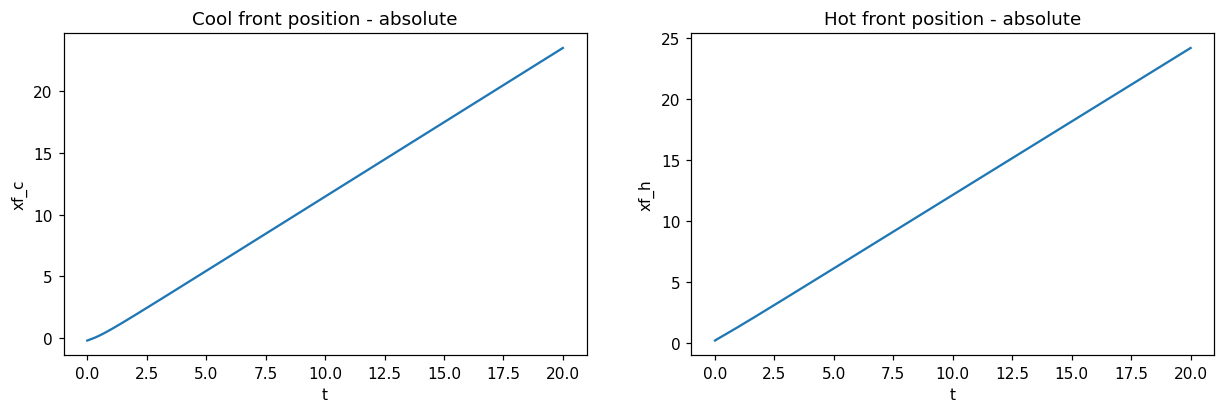

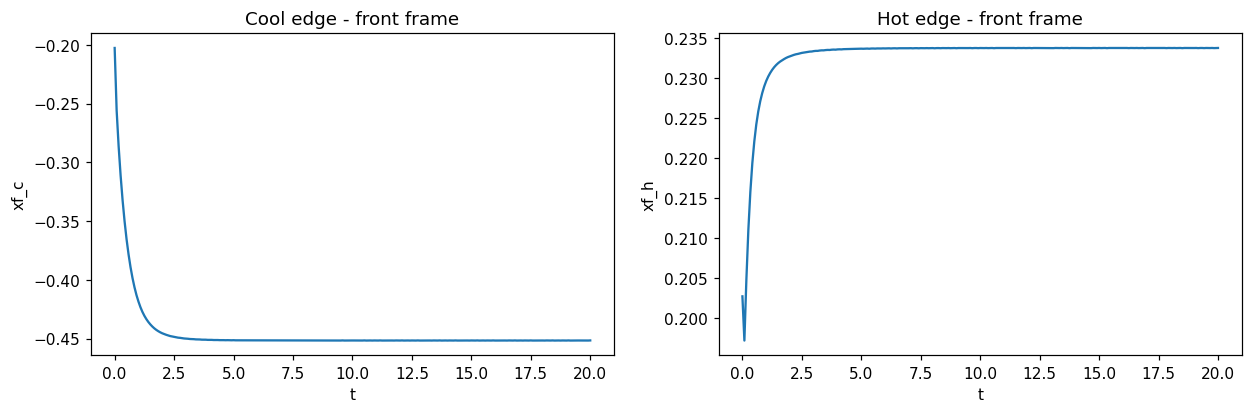

In [10]:
t = base['t']; xf = base['xf']; wd = base['wd']; wc = base['wc']; wh = base['wh']; xfc = base['xfc']; xfh = base['xfh']
vf = np.gradient(xf, t)

fig, axs = plt.subplots(1, 3, figsize=(13.5, 3.8))
axs[0].plot(t, xf); axs[0].set_xlabel('t'); axs[0].set_ylabel(r'$x_f$')
axs[0].set_title('Front position')
i0 = np.searchsorted(t, 1.0)
axs[0].plot(t, xf[i0] + v_est*(t - t[i0]), 'k--', lw=1, label=r'slope $v_{est}$')
axs[0].legend(fontsize=8)

axs[1].plot(t, vf); axs[1].axhline(v_est, ls='--', c='k', lw=1, label=r'$v_{est}$')
axs[1].set_xlabel('t'); axs[1].set_ylabel(r'$v_f=dx_f/dt$')
axs[1].set_title('Front speed'); axs[1].legend(fontsize=8)

axs[2].plot(t, wd); axs[2].axhline(l_est, ls='--', c='k', lw=1, label=r'$l_{est}$')
axs[2].set_xlabel('t'); axs[2].set_ylabel(r'$l_{10-90}$')
axs[2].set_title('Interface width'); axs[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

fig, axs = plt.subplots(1, 2, figsize=(13.5, 3.8))
axs[0].plot(t, wc); axs[0].set_xlabel('t'); axs[0].set_ylabel(r'w_c')
axs[0].set_title('Cool width')
axs[1].plot(t, wh); axs[1].set_xlabel('t'); axs[1].set_ylabel(r'w_h')
axs[1].set_title('Hot width')

fig, axs = plt.subplots(1, 2, figsize=(13.5, 3.8))
axs[0].plot(t, xfc); axs[0].set_xlabel('t'); axs[0].set_ylabel(r'xf_c')
axs[0].set_title('Cool front position - absolute')
axs[1].plot(t, xfh); axs[1].set_xlabel('t'); axs[1].set_ylabel(r'xf_h')
axs[1].set_title('Hot front position - absolute')


fig, axs = plt.subplots(1, 2, figsize=(13.5, 3.8))
axs[0].plot(t, xfc - xf); axs[0].set_xlabel('t'); axs[0].set_ylabel(r'xf_c')
axs[0].set_title('Cool edge - front frame')
axs[1].plot(t, xfh - xf); axs[1].set_xlabel('t'); axs[1].set_ylabel(r'xf_h')
axs[1].set_title('Hot edge - front frame')

print(f"late-time mean speed  ~ {np.nanmean(vf[t>4]): .4f}   (v_est = {v_est:.4f})")
print(f"late-time mean width  ~ {np.nanmean(wd[t>4]): .4f}   (l_est = {l_est:.4f})")

# Convergence checks

Check convergence with respect to $\Delta x, \Delta t, L, \text{and } w_0$. We compare the late-time mean front speed and late-time mean width.

In [11]:
def late_stats(r, tmin=4.0):
    v = np.gradient(r['xf'], r['t'])
    m = r['t'] > tmin
    return np.nanmean(v[m]), np.nanmean(r['wd'][m])

print('dx:')
for Ni in [401, 801, 1601]:
    r = simulate(N=Ni, t_end=6.0)
    v, w = late_stats(r)
    print(f"  N={Ni:5d}  dx={r['dx']:.4f}  dt={r['dt']:.2e}  late_v={v:.4f}  late_w={w:.4f}")

print('dt:')
for c in [0.4, 0.2, 0.1]:
    r = simulate(N=801, t_end=6.0, cfl=c)
    v, w = late_stats(r)
    print(f"  cfl={c:.2f}  dt={r['dt']:.2e}  late_v={v:.4f}  late_w={w:.4f}")

print('L:')
for Li in [20.0, 40.0, 80.0]:
    Ni = int(round(Li/0.05))
    r = simulate(L=Li, N=Ni, t_end=6.0)
    v, w = late_stats(r)
    print(f"  L={Li:5.0f}  N={Ni:5d}  late_v={v:.4f}  late_w={w:.4f}")

print('w0:')
for wi in [0.5, 1.0, 2.0]:
    r = simulate(w0=wi, t_end=6.0)
    v, w = late_stats(r)
    print(f"  w0={wi:.2f}  late_v={v:.4f}  late_w={w:.4f}")

dx:
  N=  401  dx=0.1500  dt=9.00e-03  late_v=1.1893  late_w=10.5455
  N=  801  dx=0.0750  dt=2.25e-03  late_v=1.2017  late_w=10.5811
  N= 1601  dx=0.0375  dt=5.63e-04  late_v=1.2034  late_w=10.5862
dt:
  cfl=0.40  dt=2.25e-03  late_v=1.2017  late_w=10.5811
  cfl=0.20  dt=1.12e-03  late_v=1.2017  late_w=10.5811
  cfl=0.10  dt=5.62e-04  late_v=1.2017  late_w=10.5811
L:
  L=   20  N=  400  late_v=1.2018  late_w=10.5728
  L=   40  N=  800  late_v=1.2033  late_w=10.5925
  L=   80  N= 1600  late_v=1.2032  late_w=10.5836
w0:
  w0=0.50  late_v=1.2027  late_w=10.1876
  w0=1.00  late_v=1.2035  late_w=10.5916
  w0=2.00  late_v=1.2088  late_w=11.8840


# $\kappa$ vs Characteristic Scales

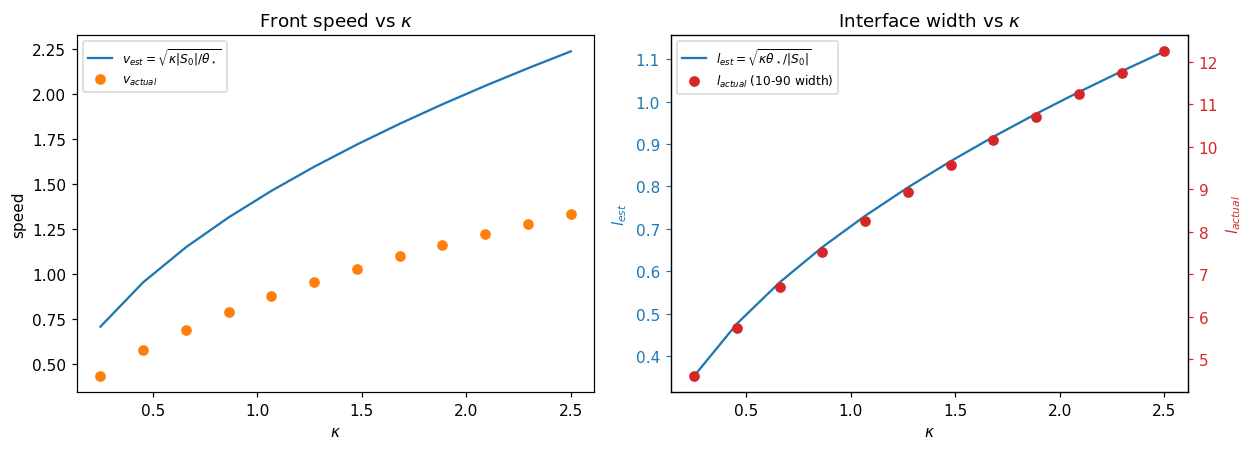

In [12]:
def plot_scales_vs_kappa(kappas=None, S0=-1.0, theta_star=0.5, eps=0.1,
                         t_end=5.0, **sim_kw):
    if kappas is None:
        kappas = np.linspace(0.25, 2.5, 12)
    Vest = np.sqrt(kappas*abs(S0)/theta_star)
    Lest = np.sqrt(kappas*theta_star/abs(S0))
    Vact = np.zeros_like(kappas); Lact = np.zeros_like(kappas)
    for i, kap in enumerate(kappas):
        r = simulate(kappa=kap, S0=S0, theta_star=theta_star, eps=eps,
                     t_end=t_end, **sim_kw)
        m = r['t'] > 0.5*r['t'][-1]
        Vact[i] = np.polyfit(r['t'][m], r['xf'][m], 1)[0]
        Lact[i] = np.nanmean(r['wd'][m])

    cv = np.sum(Vact*np.sqrt(kappas))/np.sum(kappas)
    cl = np.sum(Lact*np.sqrt(kappas))/np.sum(kappas)

    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.2))
    axs[0].plot(kappas, Vest, '-', color='C0', label=r'$v_{est}=\sqrt{\kappa|S_0|/\theta_\star}$')
    axs[0].plot(kappas, Vact, 'o', color='C1', label=r'$v_{actual}$')
    axs[0].set_xlabel(r'$\kappa$'); axs[0].set_ylabel('speed')
    axs[0].set_title(r'Front speed vs $\kappa$'); axs[0].legend(fontsize=8)

    axL = axs[1]; axR = axL.twinx()
    p1,=axL.plot(kappas, Lest, '-', color='C0', label=r'$l_{est}=\sqrt{\kappa\theta_\star/|S_0|}$')
    p2,=axR.plot(kappas, Lact, 'o', color='C3', label=r'$l_{actual}$ (10-90 width)')
    axL.set_xlabel(r'$\kappa$'); axL.set_ylabel(r'$l_{est}$', color='C0')
    axR.set_ylabel(r'$l_{actual}$', color='C3')
    axL.tick_params(axis='y', colors='C0'); axR.tick_params(axis='y', colors='C3')
    axL.set_title(r'Interface width vs $\kappa$')
    axL.legend(handles=[p1,p2], fontsize=8, loc='upper left')
    plt.tight_layout(); plt.show()
    return dict(kappas=kappas, Vest=Vest, Vact=Vact, Lest=Lest, Lact=Lact)

scales_kappa = plot_scales_vs_kappa()

# $\epsilon$ vs characteristic scales

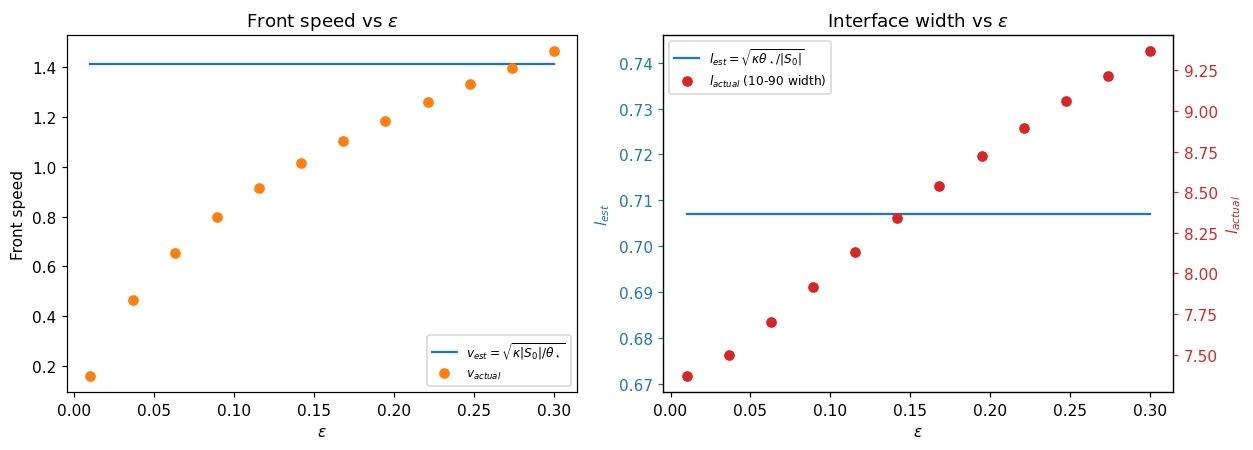

In [13]:
def plot_scales_vs_eps(epses=None, S0=-1.0, theta_star=0.5, kappa=1.0,
                         t_end=5.0, **sim_kw):
    if epses is None:
        epses = np.linspace(0.01, 0.3, 12)
    Vest = np.full_like(epses, np.sqrt(kappa*abs(S0)/theta_star), dtype=float)
    Lest = np.full_like(epses, np.sqrt(kappa*theta_star/abs(S0)), dtype=float)
    Vact = np.zeros_like(epses, dtype=float); Lact = np.zeros_like(epses, dtype=float)
    for i, ep in enumerate(epses):
        r = simulate(eps=ep, S0=S0, theta_star=theta_star, kappa=kappa,
                     t_end=t_end, **sim_kw)
        m = r['t'] > 0.5*r['t'][-1]
        Vact[i] = np.polyfit(r['t'][m], r['xf'][m], 1)[0]
        Lact[i] = np.nanmean(r['wd'][m])

    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.2))
    axs[0].plot(epses, Vest, '-', color='C0', label=r'$v_{est}=\sqrt{\kappa|S_0|/\theta_\star}$')
    axs[0].plot(epses, Vact, 'o', color='C1', label=r'$v_{actual}$')
    axs[0].set_xlabel(r'$\epsilon$')
    axs[0].set_ylabel('Front speed')
    axs[0].set_title(r'Front speed vs $\epsilon$'); axs[0].legend(fontsize=8)

    axL = axs[1]; axR = axL.twinx()
    p1,=axL.plot(epses, Lest, '-', color='C0', label=r'$l_{est}=\sqrt{\kappa\theta_\star/|S_0|}$')
    p2,=axR.plot(epses, Lact, 'o', color='C3', label=r'$l_{actual}$ (10-90 width)')
    axL.set_xlabel(r'$\epsilon$'); axL.set_ylabel(r'$l_{est}$', color='C0')
    axR.set_ylabel(r'$l_{actual}$', color='C3')
    axL.tick_params(axis='y', colors='C0'); axR.tick_params(axis='y', colors='C3')
    axL.set_title(r'Interface width vs $\epsilon$')
    axL.legend(handles=[p1,p2], fontsize=8, loc='upper left')
    plt.tight_layout(); plt.show()
    return dict(epses=epses, Vest=Vest, Vact=Vact, Lest=Lest, Lact=Lact)

scales_eps = plot_scales_vs_eps()

# $\theta_*$ vs characteristic scales

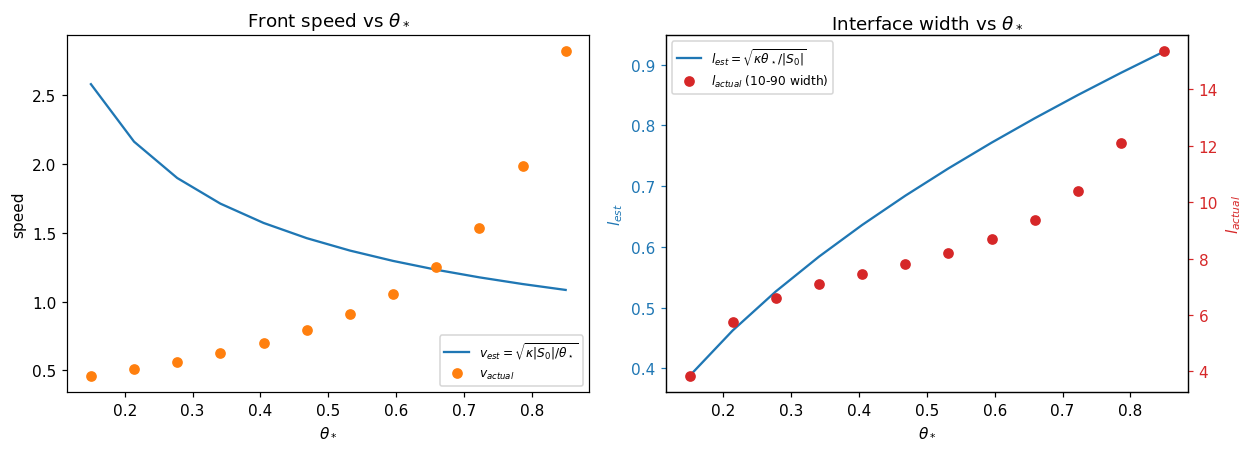

In [14]:
# check if needs fixing
def plot_scales_vs_thetastar(thetastars=None, S0=-1.0, kappa=1.0, eps=0.1,
                         t_end=5.0, **sim_kw):
    if thetastars is None:
        thetastars = np.linspace(0.15, 0.85, 12)
    Vest = np.sqrt(kappa*abs(S0)/thetastars)
    Lest = np.sqrt(kappa*thetastars/abs(S0))
    Vact = np.zeros_like(thetastars); Lact = np.zeros_like(thetastars)
    for i, thetast in enumerate(thetastars):
        r = simulate(theta_star=thetast, S0=S0, kappa=kappa, eps=eps,
                     t_end=t_end, **sim_kw)
        m = r['t'] > 0.5*r['t'][-1]
        Vact[i] = np.polyfit(r['t'][m], r['xf'][m], 1)[0]
        Lact[i] = np.nanmean(r['wd'][m])

    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.2))
    axs[0].plot(thetastars, Vest, '-', color='C0', label=r'$v_{est}=\sqrt{\kappa|S_0|/\theta_\star}$')
    axs[0].plot(thetastars, Vact, 'o', color='C1', label=r'$v_{actual}$')
    axs[0].set_xlabel(r'$\theta_*$'); axs[0].set_ylabel('speed')
    axs[0].set_title(r'Front speed vs $\theta_*$'); axs[0].legend(fontsize=8)

    axL = axs[1]; axR = axL.twinx()
    p1,=axL.plot(thetastars, Lest, '-', color='C0', label=r'$l_{est}=\sqrt{\kappa\theta_\star/|S_0|}$')
    p2,=axR.plot(thetastars, Lact, 'o', color='C3', label=r'$l_{actual}$ (10-90 width)')
    axL.set_xlabel(r'$\theta_*$'); axL.set_ylabel(r'$l_{est}$', color='C0')
    axR.set_ylabel(r'$l_{actual}$', color='C3')
    axL.tick_params(axis='y', colors='C0'); axR.tick_params(axis='y', colors='C3')
    axL.set_title(r'Interface width vs $\theta_*$')
    axL.legend(handles=[p1,p2], fontsize=8, loc='upper left')
    plt.tight_layout(); plt.show()
    return dict(thetastars=thetastars, Vest=Vest, Vact=Vact, Lest=Lest, Lact=Lact)

scales_thetastar = plot_scales_vs_thetastar()

# $\kappa$ vs characteristic scales - log-log

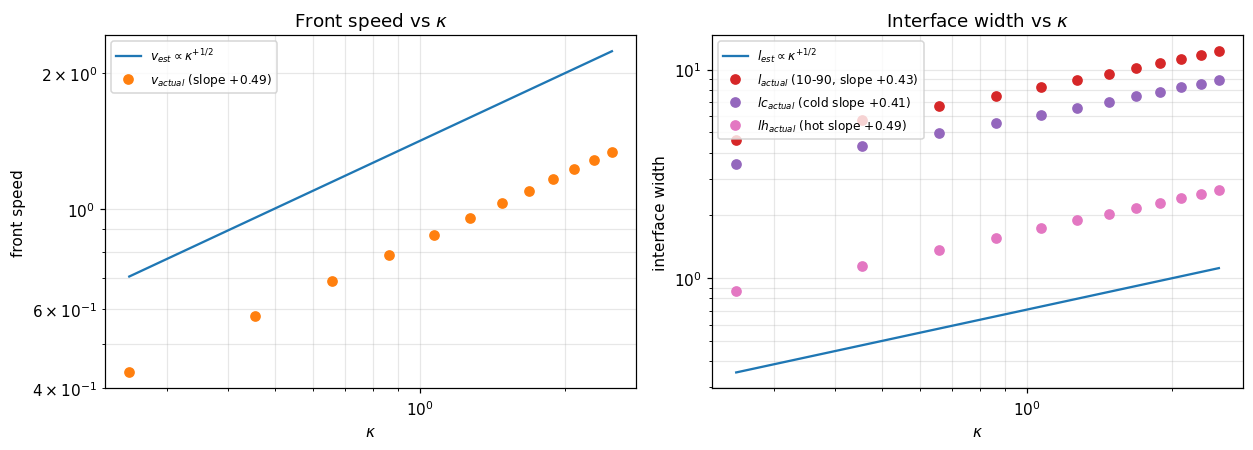

In [15]:
def plot_scales_vs_kappa(kappas=None, S0=-1.0, theta_star=0.5, eps=0.1,
                         t_end=5.0, **sim_kw):
    if kappas is None:
        kappas = np.linspace(0.25, 2.5, 12)
    kappas = np.asarray(kappas, dtype=float)
    Vest = np.sqrt(kappas*abs(S0)/theta_star)
    Lest = np.sqrt(kappas*theta_star/abs(S0))
    Vact = np.zeros_like(kappas); Lact = np.zeros_like(kappas); LCact = np.zeros_like(kappas); LHact = np.zeros_like(kappas)
    for i, kap in enumerate(kappas):
        r = simulate(kappa=kap, S0=S0, theta_star=theta_star, eps=eps,
                     t_end=t_end, **sim_kw)
        m = (r['t'] > 0.5*r['t'][-1]) & np.isfinite(r['xf'])
        Vact[i] = np.polyfit(r['t'][m], r['xf'][m], 1)[0]
        Lact[i] = np.nanmean(r['wd'][m])
        LCact[i] = np.nanmean(r['wc'][m])
        LHact[i] = np.nanmean(r['wh'][m])

    def loglog_slope(xv, yv):
        g = np.isfinite(xv) & np.isfinite(yv) & (xv > 0) & (yv > 0)
        return np.polyfit(np.log(xv[g]), np.log(yv[g]), 1)[0]
    sV, sL, sLC, sLH = loglog_slope(kappas, Vact), loglog_slope(kappas, Lact), loglog_slope(kappas, LCact), loglog_slope(kappas, LHact)

    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.2))
    axs[0].loglog(kappas, Vest, '-',  color='C0', label=r'$v_{est}\propto\kappa^{+1/2}$')
    axs[0].loglog(kappas, Vact, 'o', color='C1', label=fr'$v_{{actual}}$ (slope ${sV:+.2f}$)')
    axs[0].set_xlabel(r'$\kappa$'); axs[0].set_ylabel('front speed')
    axs[0].set_title(r'Front speed vs $\kappa$')
    axs[0].legend(fontsize=8); axs[0].grid(True, which='both', alpha=0.3)

    axs[1].loglog(kappas, Lest, '-',  color='C0', label=r'$l_{est}\propto\kappa^{+1/2}$')
    axs[1].loglog(kappas, Lact, 'o', color='C3', label=fr'$l_{{actual}}$ (10-90, slope ${sL:+.2f}$)')
    axs[1].loglog(kappas, LCact, 'o', color='C4', label=fr'$lc_{{actual}}$ (cold slope ${sLC:+.2f}$)')
    axs[1].loglog(kappas, LHact, 'o', color='C6', label=fr'$lh_{{actual}}$ (hot slope ${sLH:+.2f}$)')
    axs[1].set_xlabel(r'$\kappa$'); axs[1].set_ylabel('interface width')
    axs[1].set_title(r'Interface width vs $\kappa$')
    axs[1].legend(fontsize=8); axs[1].grid(True, which='both', alpha=0.3)

    plt.tight_layout(); plt.show()
    return dict(kappas=kappas, Vest=Vest, Vact=Vact, Lest=Lest, Lact=Lact,LCact=LCact, LHact=LHact, sV=sV, sL=sL, sLC=sLC, sLH=sLH)

scales_kappa = plot_scales_vs_kappa()

# $\epsilon$ vs characteristic scales - log-log

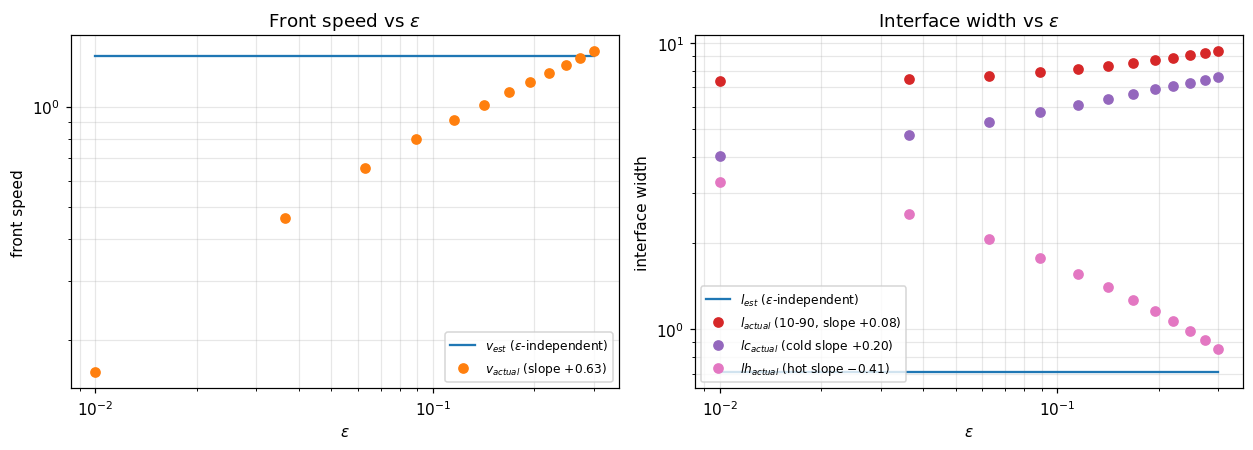

In [17]:
def plot_scales_vs_eps(epses=None, S0=-1.0, theta_star=0.5, kappa=1.0,
                       t_end=5.0, **sim_kw):
    if epses is None:
        epses = np.linspace(0.01, 0.3, 12)
    epses = np.asarray(epses, dtype=float)
    Vest = np.full_like(epses, np.sqrt(kappa*abs(S0)/theta_star))
    Lest = np.full_like(epses, np.sqrt(kappa*theta_star/abs(S0)))
    Vact = np.zeros_like(epses); Lact = np.zeros_like(epses); LCact = np.zeros_like(epses); LHact = np.zeros_like(epses)
    for i, ep in enumerate(epses):
        r = simulate(eps=ep, S0=S0, theta_star=theta_star, kappa=kappa,
                     t_end=t_end, **sim_kw)
        m = (r['t'] > 0.5*r['t'][-1]) & np.isfinite(r['xf'])
        Vact[i] = np.polyfit(r['t'][m], r['xf'][m], 1)[0]
        Lact[i] = np.nanmean(r['wd'][m])
        LCact[i] = np.nanmean(r['wc'][m])
        LHact[i] = np.nanmean(r['wh'][m])

    def loglog_slope(xv, yv):
        g = np.isfinite(xv) & np.isfinite(yv) & (xv > 0) & (yv > 0)
        return np.polyfit(np.log(xv[g]), np.log(yv[g]), 1)[0]
    sV, sL, sLC, sLH = loglog_slope(epses, Vact), loglog_slope(epses, Lact), loglog_slope(epses, LCact), loglog_slope(epses, LHact)

    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.2))
    axs[0].loglog(epses, Vest, '-',  color='C0', label=r'$v_{est}$ ($\epsilon$-independent)')
    axs[0].loglog(epses, Vact, 'o', color='C1', label=fr'$v_{{actual}}$ (slope ${sV:+.2f}$)')
    axs[0].set_xlabel(r'$\epsilon$'); axs[0].set_ylabel('front speed')
    axs[0].set_title(r'Front speed vs $\epsilon$')
    axs[0].legend(fontsize=8); axs[0].grid(True, which='both', alpha=0.3)

    axs[1].loglog(epses, Lest, '-',  color='C0', label=r'$l_{est}$ ($\epsilon$-independent)')
    axs[1].loglog(epses, Lact, 'o', color='C3', label=fr'$l_{{actual}}$ (10-90, slope ${sL:+.2f}$)')
    axs[1].loglog(epses, LCact, 'o', color='C4', label=fr'$lc_{{actual}}$ (cold slope ${sLC:+.2f}$)')
    axs[1].loglog(epses, LHact, 'o', color='C6', label=fr'$lh_{{actual}}$ (hot slope ${sLH:+.2f}$)')
    axs[1].set_xlabel(r'$\epsilon$'); axs[1].set_ylabel('interface width')
    axs[1].set_title(r'Interface width vs $\epsilon$')
    axs[1].legend(fontsize=8); axs[1].grid(True, which='both', alpha=0.3)

    plt.tight_layout(); plt.show()
    return dict(epses=epses, Vest=Vest, Vact=Vact, Lest=Lest, Lact=Lact, LCact=LCact, LHact=LHact, sV=sV, sL=sL, sLC=sLC, sLH=sLH)

scales_eps = plot_scales_vs_eps()

# $\theta_*$ vs characteristic scales - log-log

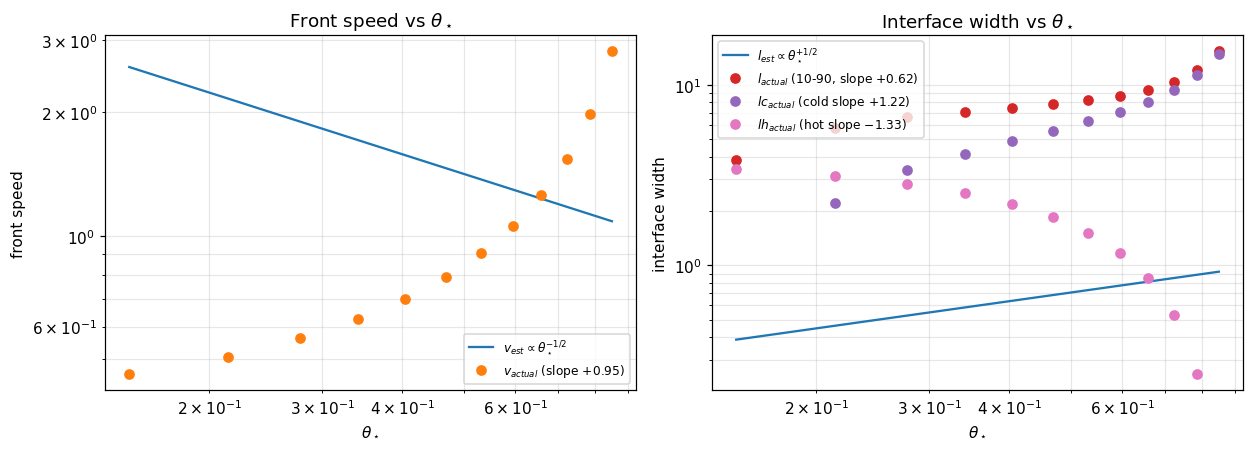

In [18]:
def plot_scales_vs_thetastar(thetastars=None, S0=-1.0, kappa=1.0, eps=0.1,
                             t_end=5.0, **sim_kw):
    if thetastars is None:
        thetastars = np.linspace(0.15, 0.85, 12)
    thetastars = np.asarray(thetastars, dtype=float)
    Vest = np.sqrt(kappa*abs(S0)/thetastars)
    Lest = np.sqrt(kappa*thetastars/abs(S0))
    Vact = np.zeros_like(thetastars); Lact = np.zeros_like(thetastars); LCact = np.zeros_like(thetastars); LHact = np.zeros_like(thetastars)
    for i, thetast in enumerate(thetastars):
        r = simulate(theta_star=thetast, S0=S0, kappa=kappa, eps=eps,
                     t_end=t_end, **sim_kw)
        m = (r['t'] > 0.5*r['t'][-1]) & np.isfinite(r['xf'])
        Vact[i] = np.polyfit(r['t'][m], r['xf'][m], 1)[0]
        Lact[i] = np.nanmean(r['wd'][m])
        LCact[i] = np.nanmean(r['wc'][m])
        LHact[i] = np.nanmean(r['wh'][m])

    def loglog_slope(xv, yv):
        g = np.isfinite(xv) & np.isfinite(yv) & (xv > 0) & (yv > 0)
        return np.polyfit(np.log(xv[g]), np.log(yv[g]), 1)[0]
    sV, sL, sLC, sLH = loglog_slope(thetastars, Vact), loglog_slope(thetastars, Lact), loglog_slope(thetastars, LCact), loglog_slope(thetastars, LHact)

    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.2))

    axs[0].loglog(thetastars, Vest, '-',  color='C0', label=r'$v_{est}\propto\theta_\star^{-1/2}$')
    axs[0].loglog(thetastars, Vact, 'o',  color='C1', label=fr'$v_{{actual}}$ (slope ${sV:+.2f}$)')
    axs[0].set_xlabel(r'$\theta_\star$'); axs[0].set_ylabel('front speed')
    axs[0].set_title(r'Front speed vs $\theta_\star$')
    axs[0].legend(fontsize=8); axs[0].grid(True, which='both', alpha=0.3)

    axs[1].loglog(thetastars, Lest, '-',  color='C0', label=r'$l_{est}\propto\theta_\star^{+1/2}$')
    axs[1].loglog(thetastars, Lact, 'o',  color='C3', label=fr'$l_{{actual}}$ (10-90, slope ${sL:+.2f}$)')
    axs[1].loglog(thetastars, LCact, 'o',  color='C4', label=fr'$lc_{{actual}}$ (cold slope ${sLC:+.2f}$)')
    axs[1].loglog(thetastars, LHact, 'o',  color='C6', label=fr'$lh_{{actual}}$ (hot slope ${sLH:+.2f}$)')
    axs[1].set_xlabel(r'$\theta_\star$'); axs[1].set_ylabel('interface width')
    axs[1].set_title(r'Interface width vs $\theta_\star$')
    axs[1].legend(fontsize=8); axs[1].grid(True, which='both', alpha=0.3)

    plt.tight_layout(); plt.show()
    return dict(thetastars=thetastars, Vest=Vest, Vact=Vact, Lest=Lest, Lact=Lact, LCact=LCact, LHact=LHact, sV=sV, sL=sL, sLC=sLC, sLH=sLH)

scales_thetastar = plot_scales_vs_thetastar()